<a href="https://colab.research.google.com/github/hjiwoong/DL/blob/main/day13_practice1_%EC%98%A4%ED%86%A0%EC%9D%B8%EC%BD%94%EB%8D%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 생성 모델 맛보기
# 오토인코더 - 압축했다 복원하면 배우는 것
# 오토인코더 = 인코더(압축) → 디코더(복원)

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 5

In [3]:
# 셀 1. 데이터(Fashion-MNIST)
def load_fmnist(root="./data"):
  tf = transforms.ToTensor() # 이미지(0-255) → 텐서(0.0-1.0)로 변환
  return datasets.FashionMNIST(root=root, train=True, download=True, transform=tf)

train_data = load_fmnist()
loader = DataLoader(train_data, batch_size=256, shuffle=True) # 256장씩 묶고 매 에폭 섞기

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.5MB/s]


In [8]:
LATENT = 32 #정보를 압축하는 크기(입력의 4%)
class AutoEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder = nn.Sequential( # 압축부
        nn.Flatten(), # 28×28 이미지를 1차원 배열
        nn.Linear(784, 128), nn.ReLU(),
        nn.Linear(128, LATENT),
    )
    self.decoder = nn.Sequential( # 복원부
        nn.Linear(LATENT, 128), nn.ReLU(),
        nn.Linear(128, 784), nn.Sigmoid(),
    )
  def forward(self, x):
    z = self.encoder(x) # z = 잠재 벡터(숫자 32개로 압축된 특징)
    return self.decoder(z).reshape(-1, 1, 28, 28) # 복원 후 이미지 모양으로 되돌림, -1은 배치 크기 자동 계산
model = AutoEncoder().to(device)
loss_fn = nn.MSELoss() # 복원본 vs 원본 픽셀 차이
opt = torch.optim.Adam(model.parameters(), lr=0.001)

In [10]:
# 셀 3. 학습 - 정답이 '자기 자신'인 학습
for epoch in range(EPOCHS):
  for images, _ in loader: # 라벨은 버린다
    images = images.to(device)
    recon = model(images) # 예측: 복원한 이미지
    loss = loss_fn(recon, images) # 손실: 복원본 vs 원본 (정답이 자기 자신)
    opt.zero_grad()
    loss.backward()
    opt.step()
  print(f"epoch {epoch+1}/{EPOCHS} | 복원 loss{loss.item():.4f}")

epoch 1/5 | 복원 loss0.0240
epoch 2/5 | 복원 loss0.0201
epoch 3/5 | 복원 loss0.0194
epoch 4/5 | 복원 loss0.0155
epoch 5/5 | 복원 loss0.0171


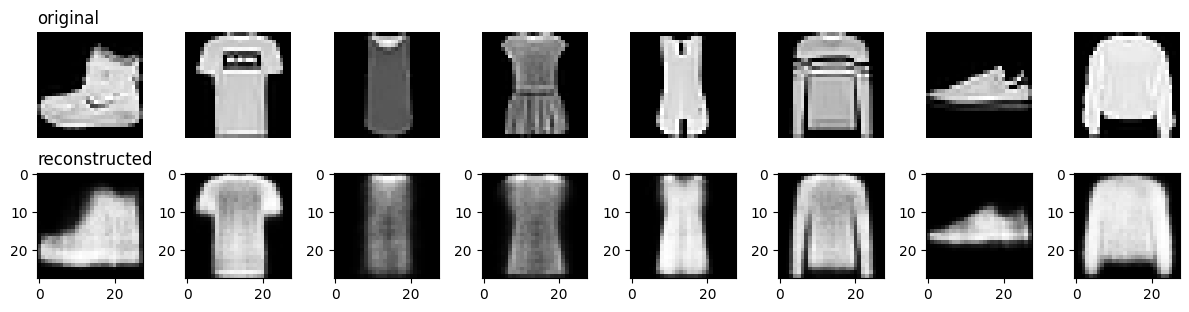

위: 원본 / 아래: 32개 숫자에서 복원된 것
잠재 벡터 예시 (한 장의 '요약' 32개 중 8개):
  [4.48, 5.26, 2.49, 10.4, -3.49, -4.05, 0.53, -3.8]


In [16]:
# 셀 4. 복원 결과
model.eval()
images, _ = next(iter(DataLoader(train_data, batch_size=8, shuffle=False))) # 배치 8장만 꺼내기
with torch.no_grad():
  recon = model(images.to(device)).cpu() # 복원 결과를 CPU로 그림 그리기 위해서
  z = model.encoder(images.to(device)).cpu() # 잠재 벡터

fig, axes = plt.subplots(2, 8, figsize=(12,3.2))
for i in range(8):
  axes[0,i].imshow(images[i][0], cmap="gray") # [0]은 (1,28,28) -> (28,28)로 채널 삭제
  axes[0,i].axis("off")
  axes[1,i].imshow(recon[i][0], cmap="gray") # 복원
axes[0,0].set_title("original", loc="left")
axes[1,0].set_title("reconstructed", loc="left")
plt.tight_layout()
plt.savefig("plot1_recon.png")
plt.show()
print("위: 원본 / 아래: 32개 숫자에서 복원된 것")
print("잠재 벡터 예시 (한 장의 '요약' 32개 중 8개):")
print(" ", [round(v,2) for v in z[0][:8].tolist()])

디노이징 학습 완료 | loss 0.0210


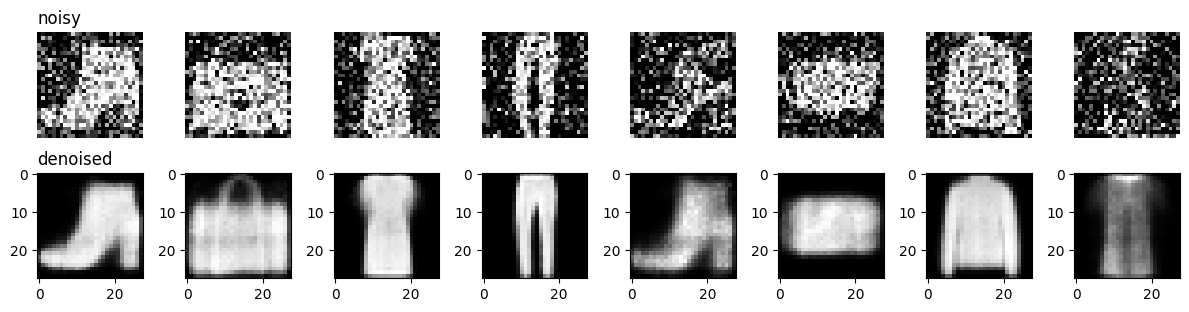

In [18]:
# 셀 5. 응용 - 노이즈 제고 오토인코더 (디노이징 오토인코더)
# 입력엔 노이즈를 섞고, 정답은 '깨끗한 원본'으로 학습 -> '노이즈 지우는 법'을 배움

model_dn = AutoEncoder().to(device)
opt = torch.optim.Adam(model_dn.parameters(), lr=0.001)

for epoch in range(EPOCHS):
  for images, _ in loader:
    images = images.to(device)
    noisy = (images + 0.4 * torch.randn_like(images)).clamp(0,1) # 노이즈 주입
    loss = loss_fn(model_dn(noisy), images) # 입력=노이즈, 정답=깨끗한 원본
    opt.zero_grad()
    loss.backward()
    opt.step()
print(f"디노이징 학습 완료 | loss {loss.item():.4f}")

model_dn.eval()
with torch.no_grad():
  noisy = (images[:8].to(device) + 0.4 * torch.randn(8, 1, 28, 28).to(device)).clamp(0,1).cpu() # 평가용 노이즈 이미지 8장 만들기
  cleaned = model_dn(noisy.to(device)).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12,3.2))
for i in range(8):
  axes[0, i].imshow(noisy[i][0], cmap="gray") # [0]은 (1,28,28) -> (28,28)로 채널 삭제
  axes[0, i].axis("off")
  axes[1, i].imshow(cleaned[i][0], cmap="gray") # 복원
axes[0, 0].set_title("noisy", loc="left")
axes[1, 0].set_title("denoised", loc="left")
plt.tight_layout()
plt.savefig("plot2_denoise.png")
plt.show()

# 이 아이디어(노이즈 제거를 배우는 것)을 극한까지 말면 '순수 노이즈에서 이미지를 만들어내는' 디퓨전 모델이 된다
# 노이즈 제거 된 이미지 결과